<a href="https://colab.research.google.com/github/Vedangi914/Vedangi/blob/main/bayesian_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install pytorch-msssim

In [ ]:
pip install nibabel opencv-python

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import nibabel as nib
import numpy as np
import cv2

input_path = r"C:\Users\Dell\Downloads\ACDC\database\testing"
output_path = r"C:\Users\Dell\Downloads\ACDC_SLICES"

os.makedirs(output_path, exist_ok=True)

for patient in os.listdir(input_path):
    patient_folder = os.path.join(input_path, patient)

    if os.path.isdir(patient_folder):

        for file in os.listdir(patient_folder):

            if "frame" in file and "_gt" not in file and file.endswith(".nii.gz"):

                nii_path = os.path.join(patient_folder, file)
                img = nib.load(nii_path)
                data = img.get_fdata()

                data = (data - np.min(data)) / (np.max(data) - np.min(data))

                for i in range(data.shape[2]):
                    slice_img = data[:,:,i]
                    slice_img = (slice_img * 255).astype(np.uint8)

                    save_name = f"{patient}_{file}_slice{i}.png"
                    cv2.imwrite(os.path.join(output_path, save_name), slice_img)

print("DONE ✅ Slices created")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Dell\\Downloads\\ACDC\\database\\testing'

Epoch: 0 Loss: 0.06449449807405472
Epoch: 1 Loss: 0.07358282804489136
Epoch: 2 Loss: 0.03491351753473282
Epoch: 3 Loss: 0.05122814327478409
Epoch: 4 Loss: 0.04441200941801071
SSIM: 0.974851131439209


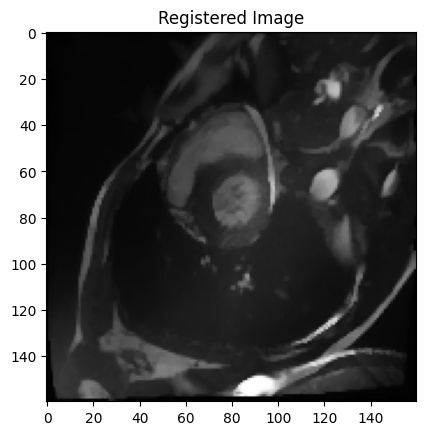

In [ ]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter, map_coordinates
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- ELASTIC DEFORMATION ----------------
def elastic_deform(image, alpha=15, sigma=3):
    random_state = np.random.RandomState(None)
    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    dy = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (y+dy).reshape(-1), (x+dx).reshape(-1)
    return map_coordinates(image, indices, order=1).reshape(shape)

# ---------------- DATASET ----------------
class LungDataset(Dataset):
    def __init__(self, folder):
        self.images = []
        for file in os.listdir(folder):
            img = cv2.imread(os.path.join(folder,file),0)
            img = cv2.resize(img,(160,160))/255.0
            self.images.append(img.astype(np.float32))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        ref = self.images[idx]
        mov = elastic_deform(ref)

        ref = torch.tensor(ref).unsqueeze(0)
        mov = torch.tensor(mov).unsqueeze(0)

        x = torch.cat([ref,mov],dim=0)
        return x, ref

# ---------------- BAYESIAN UNET ----------------
class BayesianUNet(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_c,out_c):
            return nn.Sequential(
                nn.Conv2d(in_c,out_c,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2),
                nn.Conv2d(out_c,out_c,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2)
            )
        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)
        self.enc4 = block(128,256)
        self.pool = nn.MaxPool2d(2)

        self.up3 = nn.ConvTranspose2d(256,128,2,2)
        self.dec3 = block(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        d3 = self.up3(e4)
        d3 = self.dec3(torch.cat([d3,e3],1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1],1))

        return self.out(d1)

# ---------------- WARP ----------------
def warp(image, dvf):
    B,C,H,W = image.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=image.device),
        torch.linspace(-1,1,W,device=image.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2)
    grid = grid.unsqueeze(0).repeat(B,1,1,1)

    dvf = dvf.permute(0,2,3,1)
    new_grid = grid + dvf

    return F.grid_sample(image,new_grid,align_corners=True)

# ---------------- LOSS ----------------
def loss_fn(ref,reg):
    return F.mse_loss(ref,reg) + (1-ssim(ref,reg,data_range=1))

# ---------------- LOAD DATA ----------------
dataset = LungDataset("/kaggle/input/datasets/lightyagami06/acdc-slices2/ACDC_SLICES")
loader = DataLoader(dataset,batch_size=1,shuffle=True)

# ---------------- TRAIN ----------------
model = BayesianUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

for epoch in range(5):
    for x,ref in loader:
        x,ref = x.to(device),ref.to(device)
        dvf = model(x)
        mov = x[:,1:2,:,:]
        reg = warp(mov,dvf)
        loss = loss_fn(ref,reg)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:",epoch,"Loss:",loss.item())

# ---------------- TEST ----------------
model.train()
x,ref = next(iter(loader))
x,ref = x.to(device),ref.to(device)

dvf_samples = [model(x) for _ in range(20)]
dvf = torch.mean(torch.stack(dvf_samples),dim=0)

mov = x[:,1:2,:,:]
reg = warp(mov,dvf)

print("SSIM:", ssim(ref,reg,data_range=1).item())

# SAVE
cv2.imwrite("reference.png",(ref.cpu().squeeze().numpy()*255).astype(np.uint8))
cv2.imwrite("moving.png",(mov.cpu().squeeze().numpy()*255).astype(np.uint8))
cv2.imwrite("registered.png",(reg.detach().cpu().squeeze().numpy()*255).astype(np.uint8))

plt.imshow(reg.detach().cpu().squeeze(), cmap='gray')
plt.title("Registered Image")
plt.show()

In [ ]:
!pip install pytorch-msssim

Loaded Images: 1076
Epoch: 0 Loss: 0.10617146641016006
Epoch: 1 Loss: 0.10208798199892044
Epoch: 2 Loss: 0.059321533888578415
Epoch: 3 Loss: 0.06966035813093185
Epoch: 4 Loss: 0.03126062452793121
SSIM: 0.9731032252311707


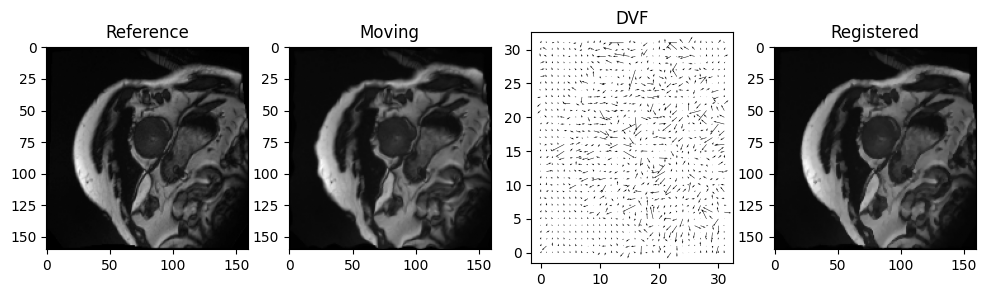

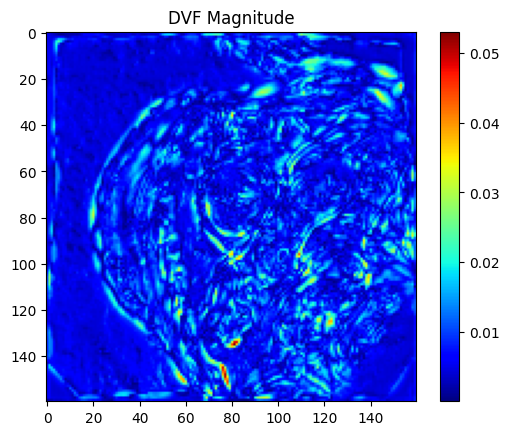

True

In [ ]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter, map_coordinates
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- ELASTIC DEFORMATION ----------------
def elastic_deform(image, alpha=15, sigma=3):
    random_state = np.random.RandomState(None)
    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    dy = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (y+dy).reshape(-1), (x+dx).reshape(-1)
    return map_coordinates(image, indices, order=1).reshape(shape)

# ---------------- DATASET ----------------
class LungDataset(Dataset):
    def __init__(self, folder):
        self.images = []

        for file in os.listdir(folder):
            path = os.path.join(folder,file)
            if file.endswith(".png"):
                img = cv2.imread(path,0)
                if img is not None:
                    img = cv2.resize(img,(160,160))/255.0
                    self.images.append(img.astype(np.float32))

        print("Loaded Images:", len(self.images))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        ref = self.images[idx]
        mov = elastic_deform(ref)

        ref = torch.tensor(ref).unsqueeze(0)
        mov = torch.tensor(mov).unsqueeze(0)

        x = torch.cat([ref,mov],dim=0)
        return x, ref

# ---------------- BAYESIAN UNET ----------------
class BayesianUNet(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_c,out_c):
            return nn.Sequential(
                nn.Conv2d(in_c,out_c,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2),
                nn.Conv2d(out_c,out_c,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2)
            )
        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)
        self.enc4 = block(128,256)
        self.pool = nn.MaxPool2d(2)

        self.up3 = nn.ConvTranspose2d(256,128,2,2)
        self.dec3 = block(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        d3 = self.up3(e4)
        d3 = self.dec3(torch.cat([d3,e3],1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1],1))

        return self.out(d1)

# ---------------- WARP ----------------
def warp(image, dvf):
    B,C,H,W = image.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=image.device),
        torch.linspace(-1,1,W,device=image.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2)
    grid = grid.unsqueeze(0).repeat(B,1,1,1)

    dvf = dvf.permute(0,2,3,1)
    new_grid = grid + dvf

    return F.grid_sample(image,new_grid,align_corners=True)

# ---------------- LOSS ----------------
def loss_fn(ref,reg):
    return F.mse_loss(ref,reg) + (1-ssim(ref,reg,data_range=1))

# ---------------- LOAD DATA ----------------
dataset = LungDataset("/kaggle/input/datasets/lightyagami06/acdc-slices2/ACDC_SLICES")
loader = DataLoader(dataset,batch_size=1,shuffle=True)

# ---------------- TRAIN ----------------
model = BayesianUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

for epoch in range(5):
    for x,ref in loader:
        x,ref = x.to(device),ref.to(device)
        dvf = model(x)
        mov = x[:,1:2,:,:]
        reg = warp(mov,dvf)

        loss = loss_fn(ref,reg)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:",epoch,"Loss:",loss.item())

# ---------------- TEST ----------------
model.train()

x,ref = next(iter(loader))
x,ref = x.to(device),ref.to(device)

dvf_samples = [model(x) for _ in range(20)]
dvf = torch.mean(torch.stack(dvf_samples),dim=0)

mov = x[:,1:2,:,:]
reg = warp(mov,dvf)

ssim_score = ssim(ref,reg,data_range=1).item()
print("SSIM:", ssim_score)

# ---------------- DVF VISUALIZATION ----------------
dvf_np = dvf.detach().cpu().squeeze().numpy()
dx = dvf_np[0]
dy = dvf_np[1]
dvf_mag = np.sqrt(dx**2 + dy**2)

# ---------------- PLOT PAPER STYLE ----------------
plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.title("Reference")
plt.imshow(ref.cpu().squeeze(), cmap='gray')

plt.subplot(1,4,2)
plt.title("Moving")
plt.imshow(mov.cpu().squeeze(), cmap='gray')

plt.subplot(1,4,3)
plt.title("DVF")
plt.quiver(dx[::5,::5], dy[::5,::5])

plt.subplot(1,4,4)
plt.title("Registered")
plt.imshow(reg.detach().cpu().squeeze(), cmap='gray')

plt.show()

# DVF HEATMAP (Paper style)
plt.figure()
plt.title("DVF Magnitude")
plt.imshow(dvf_mag, cmap='jet')
plt.colorbar()
plt.show()

# ---------------- SAVE ----------------
cv2.imwrite("reference.png",(ref.cpu().squeeze().numpy()*255).astype(np.uint8))
cv2.imwrite("moving.png",(mov.cpu().squeeze().numpy()*255).astype(np.uint8))
cv2.imwrite("registered.png",(reg.detach().cpu().squeeze().numpy()*255).astype(np.uint8))
cv2.imwrite("dvf.png",(dvf_mag*255).astype(np.uint8))

In [ ]:
# ==============================
# 1. IMPORTS
# ==============================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import os
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# 2. DATASET
# ==============================
class RegistrationDataset(Dataset):
    def __init__(self, image_dir):
        self.paths = []
        for root, _, files in os.walk(image_dir):
            for f in files:
                if f.endswith(".jpg") or f.endswith(".png"):
                    self.paths.append(os.path.join(root, f))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], 0)
        img = cv2.resize(img, (150,150))
        img = img / 255.0

        moving = img + np.random.randn(*img.shape)*0.05
        moving = np.clip(moving, 0, 1)

        ref = torch.tensor(img).float().unsqueeze(0)
        moving = torch.tensor(moving).float().unsqueeze(0)

        return ref, moving


# ==============================
# 3. MODEL (Bayesian UNet)
# ==============================
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

class BayesianUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(2,32)
        self.enc2 = ConvBlock(32,64)
        self.enc3 = ConvBlock(64,128)

        self.pool = nn.MaxPool2d(2)

        self.dec2 = ConvBlock(128+64,64)
        self.dec1 = ConvBlock(64+32,32)

        self.out = nn.Conv2d(32,2,3,padding=1)

    def forward(self, ref, mov):
        x = torch.cat([ref,mov], dim=1)

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = F.interpolate(e3, scale_factor=2)
        d2 = self.dec2(torch.cat([d2,e2],dim=1))

        d1 = F.interpolate(d2, scale_factor=2)
        d1 = self.dec1(torch.cat([d1,e1],dim=1))

        dvf = self.out(d1)
        return dvf


# ==============================
# 4. WARP FUNCTION
# ==============================
def warp(moving, dvf):
    B, C, H, W = moving.shape

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H),
        torch.linspace(-1,1,W),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).to(device)
    grid = grid.unsqueeze(0).repeat(B,1,1,1)

    dvf = dvf.permute(0,2,3,1)

    new_grid = grid + dvf

    warped = F.grid_sample(moving, new_grid, align_corners=True)
    return warped


# ==============================
# 5. LOSS FUNCTION
# ==============================
def loss_fn(ref, reg):
    mse = F.mse_loss(ref, reg)

    mu_x = ref.mean()
    mu_y = reg.mean()

    sigma_x = ref.var()
    sigma_y = reg.var()
    sigma_xy = ((ref-mu_x)*(reg-mu_y)).mean()

    C1 = 0.01**2
    C2 = 0.03**2

    ssim = ((2*mu_x*mu_y + C1)*(2*sigma_xy + C2)) / \
           ((mu_x**2 + mu_y**2 + C1)*(sigma_x + sigma_y + C2))

    return mse + (1-ssim)


# ==============================
# 6. LOAD DATA
# ==============================
dataset = RegistrationDataset("/kaggle/input/notebooks/kirollosashraf/oasis-alzheimer-s-detection")

loader = DataLoader(dataset, batch_size=4, shuffle=True)


# ==============================
# 7. TRAINING
# ==============================
model = BayesianUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for ref, mov in loader:
        ref = ref.to(device)
        mov = mov.to(device)

        dvf = model(ref, mov)
        reg = warp(mov, dvf)

        loss = loss_fn(ref, reg)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader)}")


# ==============================
# 8. VISUALIZATION
# ==============================
ref, mov = dataset[0]

model.eval()
with torch.no_grad():
    ref = ref.unsqueeze(0).to(device)
    mov = mov.unsqueeze(0).to(device)

    dvf = model(ref, mov)
    reg = warp(mov, dvf)

ref = ref.cpu().squeeze()
mov = mov.cpu().squeeze()
reg = reg.cpu().squeeze()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Reference")
plt.imshow(ref, cmap='gray')

plt.subplot(1,3,2)
plt.title("Moving")
plt.imshow(mov, cmap='gray')

plt.subplot(1,3,3)
plt.title("Registered")
plt.imshow(reg, cmap='gray')

plt.show()

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 74 but got size 75 for tensor number 1 in the list.

In [ ]:
# INSTALL
!pip install nibabel pytorch-msssim

Skipping broken: patient007
Skipping broken: patient016
Skipping broken: patient034
Skipping broken: patient067
Skipping broken: patient052
Skipping broken: patient024
Skipping broken: patient044
Skipping broken: patient066
Skipping broken: patient074
Skipping broken: patient042
Skipping broken: patient097
Skipping broken: patient089
Skipping broken: patient091
Skipping broken: patient061
Skipping broken: patient054
Skipping broken: patient082
Skipping broken: patient100
Skipping broken: patient002
Skipping broken: patient028
Skipping broken: patient085
Skipping broken: patient022
Skipping broken: patient006
Skipping broken: patient025
Skipping broken: patient051
Skipping broken: patient095
Skipping broken: patient048
Skipping broken: patient049
Skipping broken: patient005
Skipping broken: patient045
Skipping broken: patient046
Skipping broken: patient038
Skipping broken: patient013
Skipping broken: patient040
Skipping broken: patient012
Skipping broken: patient060
Skipping broken: pat

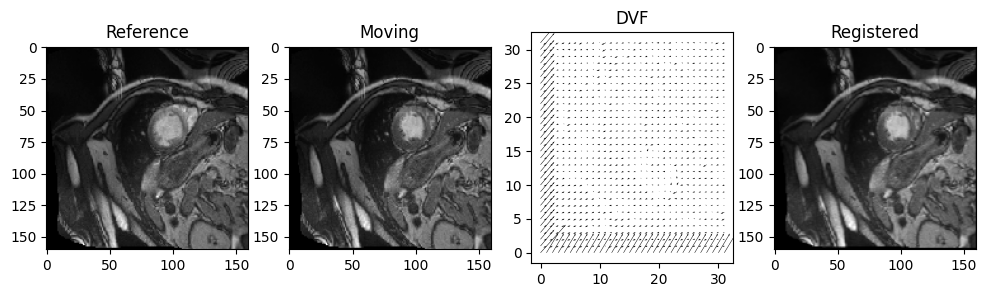

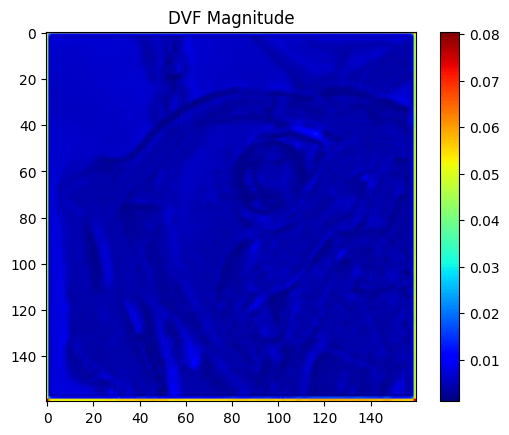

In [ ]:
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATASET ----------------
class ACDCDataset(Dataset):
    def __init__(self, root):
        self.pairs = []

        for patient in os.listdir(root):
            patient_path = os.path.join(root, patient)

            if not os.path.isdir(patient_path):
                continue

            files = os.listdir(patient_path)

            # Get valid frames
            frames = [
                f for f in files
                if ("frame" in f and "_gt" not in f and f.endswith(".nii"))
            ]

            if len(frames) < 2:
                continue

            # Sort frames numerically
            frames.sort(key=lambda x: int(x.split("frame")[1].split(".")[0]))

            ref_path = os.path.join(patient_path, frames[0])
            mov_path = os.path.join(patient_path, frames[-1])

            # ✅ SAFE CHECK (instead of getsize)
            try:
                nib.load(ref_path)
                nib.load(mov_path)
                self.pairs.append((ref_path, mov_path))
            except:
                print("Skipping broken:", patient)

        print("✅ Valid Pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ref_path, mov_path = self.pairs[idx]

        ref_img = nib.load(ref_path).get_fdata()
        mov_img = nib.load(mov_path).get_fdata()

        z = ref_img.shape[2] // 2

        ref = ref_img[:,:,z]
        mov = mov_img[:,:,z]

        ref = (ref - ref.min()) / (ref.max() - ref.min() + 1e-8)
        mov = (mov - mov.min()) / (mov.max() - mov.min() + 1e-8)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0), size=(160,160)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0), size=(160,160)).squeeze(0)

        x = torch.cat([ref, mov], dim=0)

        return x, ref, mov

# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU()
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1],1))

        return self.out(d1)

# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid+dvf, align_corners=True)

# ---------------- LOAD DATA ----------------
dataset = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")
loader = DataLoader(dataset, batch_size=1, shuffle=True)

# ---------------- TRAIN ----------------
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    for x, ref, mov in loader:
        x, ref, mov = x.to(device), ref.to(device), mov.to(device)

        dvf = model(x)
        reg = warp(mov, dvf)

        loss = F.mse_loss(ref, reg) + (1 - ssim(ref, reg, data_range=1))

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Epoch:", epoch, "Loss:", loss.item())

# ---------------- TEST ----------------
x, ref, mov = next(iter(loader))
x, ref, mov = x.to(device), ref.to(device), mov.to(device)

dvf = model(x)
reg = warp(mov, dvf)

print("SSIM:", ssim(ref, reg, data_range=1).item())

# ---------------- VISUALIZATION ----------------
dvf_np = dvf.detach().cpu().squeeze().numpy()
dx, dy = dvf_np[0], dvf_np[1]
mag = np.sqrt(dx**2 + dy**2)

plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.title("Reference")
plt.imshow(ref.cpu().squeeze(), cmap='gray')

plt.subplot(1,4,2)
plt.title("Moving")
plt.imshow(mov.cpu().squeeze(), cmap='gray')

plt.subplot(1,4,3)
plt.title("DVF")
plt.quiver(dx[::5,::5], dy[::5,::5])

plt.subplot(1,4,4)
plt.title("Registered")
plt.imshow(reg.detach().cpu().squeeze(), cmap='gray')

plt.show()

plt.figure()
plt.title("DVF Magnitude")
plt.imshow(mag, cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
!pip install SimpleITK


HDF5-DIAG: Error detected in HDF5 (1.12.1) thread 0:
  #000: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5Fdeprec.c line 156 in itk_H5Fis_hdf5(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLcallback.c line 3769 in itk_H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLcallback.c line 3699 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLnative_file.c line 384 in itk_H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Unable to initialize object
  #004: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhd

Skipping: patient007 Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient007/patient007_frame01.nii"
Skipping: patient016 Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient016/patient016_frame01.nii"
Skipping: patient034 Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient034/patient034_frame01.nii"
Skipping: patient067 Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Una

HDF5-DIAG: Error detected in HDF5 (1.12.1) thread 0:
  #000: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5Fdeprec.c line 156 in itk_H5Fis_hdf5(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLcallback.c line 3769 in itk_H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLcallback.c line 3699 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLnative_file.c line 384 in itk_H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Unable to initialize object
  #004: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhd

Skipping: patient022 Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient022/patient022_frame01.nii"
Skipping: patient006 Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient006/patient006_frame01.nii"
Skipping: patient025 Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient025/patient025_frame01.nii"
Skipping: patient051 Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Una

HDF5-DIAG: Error detected in HDF5 (1.12.1) thread 0:
  #000: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5Fdeprec.c line 156 in itk_H5Fis_hdf5(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLcallback.c line 3769 in itk_H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLcallback.c line 3699 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLnative_file.c line 384 in itk_H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Unable to initialize object
  #004: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhd

...

Epoch: 2 Loss: 0.3130812644958496


NiftiImageIO (0x4fdddca0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient057/patient057_frame09.nii has unexpected scales in sform

NiftiImageIO (0x4fdddca0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient057/patient057_frame09.nii has unexpected scales in sform

NiftiImageIO (0x4fd805d0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient019/patient019_frame01.nii has unexpected scales in sform

NiftiImageIO (0x4fd805d0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient019/patient019_frame01.nii has unexpected scales in sform

NiftiImageIO (0x4fdddca0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient019/patient019_frame11.nii has unexpected scales in sform

NiftiImageIO (0x4fdddca0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient019/patient019_frame11.nii has unexpected scales in sform

NiftiImage

Epoch: 3 Loss: 0.18855832517147064


NiftiImageIO (0x4fd805d0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient079/patient079_frame01.nii has unexpected scales in sform

NiftiImageIO (0x4fd805d0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient079/patient079_frame01.nii has unexpected scales in sform

NiftiImageIO (0x4fdddca0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient079/patient079_frame11.nii has unexpected scales in sform

NiftiImageIO (0x4fdddca0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient079/patient079_frame11.nii has unexpected scales in sform

NiftiImageIO (0x4fd805d0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient057/patient057_frame01.nii has unexpected scales in sform

NiftiImageIO (0x4fd805d0): /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training/patient057/patient057_frame01.nii has unexpected scales in sform

NiftiImage

Epoch: 4 Loss: 0.07119517028331757
SSIM: 0.8473989963531494


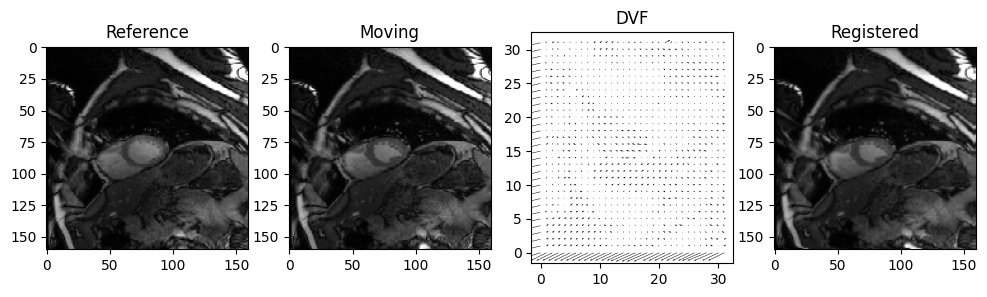

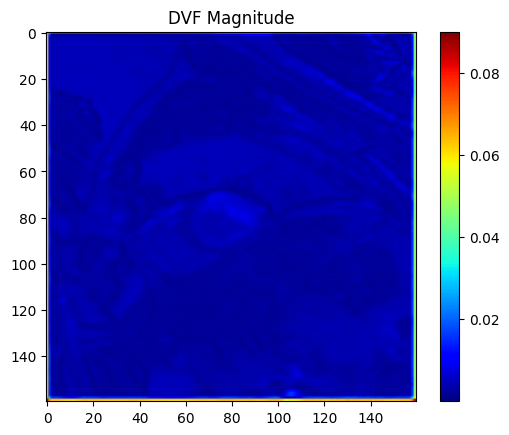

In [ ]:
import nibabel as nib
import SimpleITK as sitk
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATASET ----------------
class ACDCDataset(Dataset):
    def __init__(self, root):
        self.pairs = []

        for patient in os.listdir(root):
            patient_path = os.path.join(root, patient)

            if not os.path.isdir(patient_path):
                continue

            files = os.listdir(patient_path)

            frames = [
                f for f in files
                if ("frame" in f and "_gt" not in f and f.endswith(".nii"))
            ]

            if len(frames) < 2:
                continue

            # Sort properly
            frames.sort(key=lambda x: int(x.split("frame")[1].split(".")[0]))

            ref_path = os.path.join(patient_path, frames[0])
            mov_path = os.path.join(patient_path, frames[-1])

            try:
                # ✅ LOAD USING SimpleITK
                ref_img = sitk.GetArrayFromImage(sitk.ReadImage(ref_path))
                mov_img = sitk.GetArrayFromImage(sitk.ReadImage(mov_path))

                self.pairs.append((ref_path, mov_path))

            except Exception as e:
                print("Skipping:", patient, e)

        print("✅ Valid Pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ref_path, mov_path = self.pairs[idx]

        ref_img = sitk.GetArrayFromImage(sitk.ReadImage(ref_path))
        mov_img = sitk.GetArrayFromImage(sitk.ReadImage(mov_path))

        # SITK gives (Z,H,W) → convert to (H,W,Z)
        ref_img = np.transpose(ref_img, (1,2,0))
        mov_img = np.transpose(mov_img, (1,2,0))

        z = ref_img.shape[2] // 2

        ref = ref_img[:,:,z]
        mov = mov_img[:,:,z]

        ref = (ref - ref.min()) / (ref.max() - ref.min() + 1e-8)
        mov = (mov - mov.min()) / (mov.max() - mov.min() + 1e-8)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0), size=(160,160)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0), size=(160,160)).squeeze(0)

        x = torch.cat([ref, mov], dim=0)

        return x, ref, mov

# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU()
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1],1))

        return self.out(d1)

# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid+dvf, align_corners=True)

# ---------------- LOAD DATA ----------------
dataset = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")
loader = DataLoader(dataset, batch_size=1, shuffle=True)

# ---------------- TRAIN ----------------
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    for x, ref, mov in loader:
        x, ref, mov = x.to(device), ref.to(device), mov.to(device)

        dvf = model(x)
        reg = warp(mov, dvf)

        loss = F.mse_loss(ref, reg) + (1 - ssim(ref, reg, data_range=1))

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Epoch:", epoch, "Loss:", loss.item())

# ---------------- TEST ----------------
x, ref, mov = next(iter(loader))
x, ref, mov = x.to(device), ref.to(device), mov.to(device)

dvf = model(x)
reg = warp(mov, dvf)

print("SSIM:", ssim(ref, reg, data_range=1).item())

# ---------------- VISUALIZATION ----------------
dvf_np = dvf.detach().cpu().squeeze().numpy()
dx, dy = dvf_np[0], dvf_np[1]
mag = np.sqrt(dx**2 + dy**2)

plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.title("Reference")
plt.imshow(ref.cpu().squeeze(), cmap='gray')

plt.subplot(1,4,2)
plt.title("Moving")
plt.imshow(mov.cpu().squeeze(), cmap='gray')

plt.subplot(1,4,3)
plt.title("DVF")
plt.quiver(dx[::5,::5], dy[::5,::5])

plt.subplot(1,4,4)
plt.title("Registered")
plt.imshow(reg.detach().cpu().squeeze(), cmap='gray')

plt.show()

plt.figure()
plt.title("DVF Magnitude")
plt.imshow(mag, cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
import os

root = "/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training"

count = 0
for patient in os.listdir(root):
    p = os.path.join(root, patient)
    if os.path.isdir(p):
        files = os.listdir(p)
        nii_files = [f for f in files if f.endswith(".nii") and "_gt" not in f]
        print(patient, "→", len(nii_files))
        count += 1

print("Total patients:", count)

patient007 → 3
patient016 → 3
patient034 → 3
patient067 → 3
patient052 → 3
patient024 → 3
patient044 → 3
patient066 → 3
patient074 → 3
patient042 → 3
patient097 → 3
patient089 → 3
patient091 → 3
patient061 → 3
patient054 → 3
patient082 → 3
patient099 → 3
patient100 → 3
patient002 → 3
patient028 → 3
patient085 → 3
patient022 → 3
patient006 → 3
patient025 → 3
patient051 → 3
patient095 → 3
patient048 → 3
patient049 → 3
patient005 → 3
patient045 → 3
patient046 → 3
patient038 → 3
patient013 → 3
patient040 → 3
patient012 → 3
patient060 → 3
patient023 → 3
patient098 → 3
patient050 → 3
patient064 → 3
patient080 → 3
patient021 → 3
patient092 → 3
patient086 → 3
patient018 → 3
patient072 → 3
patient008 → 3
patient065 → 3
patient020 → 3
patient076 → 3
patient079 → 3
patient003 → 3
patient059 → 3
patient043 → 3
patient004 → 3
patient032 → 3
patient088 → 3
patient041 → 3
patient031 → 3
patient019 → 3
patient033 → 3
patient083 → 3
patient071 → 3
patient057 → 3
patient053 → 3
patient084 → 3
patient035

In [ ]:
!pip install SimpleITK pytorch-msssim

🔥 Total Candidate Pairs: 100
Epoch 0 Loss: 0.1465
Epoch 1 Loss: 0.1080
Epoch 2 Loss: 0.1235
Epoch 3 Loss: 0.1467
Epoch 4 Loss: 0.0568
SSIM: 0.9157222509384155


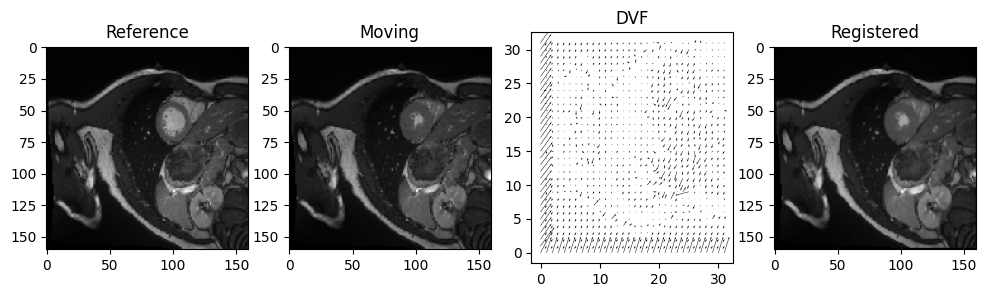

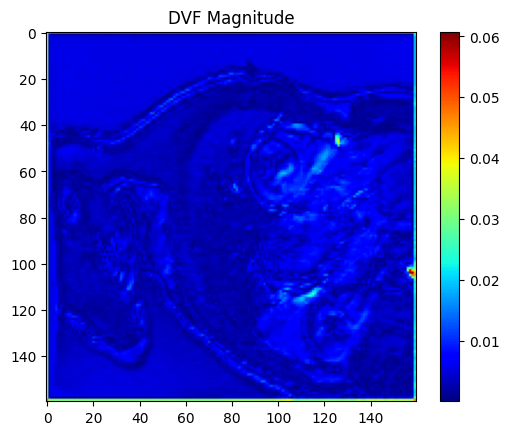

In [ ]:
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATASET ----------------
import re


import SimpleITK as sitk
import re

import nibabel as nib
import SimpleITK as sitk
import re

import nibabel as nib
import re

class ACDCDataset(Dataset):
    def __init__(self, root):
        self.pairs = []

        for patient in os.listdir(root):
            patient_path = os.path.join(root, patient)

            if not os.path.isdir(patient_path):
                continue

            files = os.listdir(patient_path)

            frames = []
            for f in files:
                match = re.match(r".*frame(\d+)\.nii$", f)
                if match and "_gt" not in f and "_4d" not in f:
                    frames.append((int(match.group(1)), f))

            if len(frames) < 2:
                continue

            frames.sort(key=lambda x: x[0])

            ref_path = os.path.join(patient_path, frames[0][1])
            mov_path = os.path.join(patient_path, frames[-1][1])

            # ✅ ONLY STORE PATHS (NO LOADING HERE)
            self.pairs.append((ref_path, mov_path))

        print("🔥 Total Candidate Pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ref_path, mov_path = self.pairs[idx]

        try:
            ref_img = nib.load(ref_path).get_fdata()
            mov_img = nib.load(mov_path).get_fdata()
        except:
            # skip bad sample
            return self.__getitem__((idx + 1) % len(self.pairs))

        z = ref_img.shape[2] // 2

        ref = ref_img[:, :, z]
        mov = mov_img[:, :, z]

        ref = (ref - ref.min()) / (ref.max() - ref.min() + 1e-8)
        mov = (mov - mov.min()) / (mov.max() - mov.min() + 1e-8)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0), size=(160,160)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0), size=(160,160)).squeeze(0)

        x = torch.cat([ref, mov], dim=0)

        return x, ref, mov

# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU()
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)  # DVF

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1],1))

        return self.out(d1)


# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid+dvf, align_corners=True)


# ---------------- LOAD DATA ----------------
dataset = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")
loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,     # 🔥 speeds up loading
    pin_memory=True
)

# ---------------- TRAIN ----------------
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    for x, ref, mov in loader:
        x, ref, mov = x.to(device), ref.to(device), mov.to(device)

        dvf = model(x)
        reg = warp(mov, dvf)

        loss = F.mse_loss(ref, reg) + (1 - ssim(ref, reg, data_range=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} Loss: {loss.item():.4f}")


# ---------------- TEST ----------------
x, ref, mov = next(iter(loader))
x, ref, mov = x.to(device), ref.to(device), mov.to(device)

dvf = model(x)
reg = warp(mov, dvf)

print("SSIM:", ssim(ref, reg, data_range=1).item())


# ---------------- VISUALIZATION ----------------
dvf_np = dvf.detach().cpu().squeeze().numpy()
dx, dy = dvf_np[0], dvf_np[1]
mag = np.sqrt(dx**2 + dy**2)

plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.title("Reference")
plt.imshow(ref.cpu().squeeze(), cmap='gray')

plt.subplot(1,4,2)
plt.title("Moving")
plt.imshow(mov.cpu().squeeze(), cmap='gray')

plt.subplot(1,4,3)
plt.title("DVF")
plt.quiver(dx[::5,::5], dy[::5,::5])

plt.subplot(1,4,4)
plt.title("Registered")
plt.imshow(reg.detach().cpu().squeeze(), cmap='gray')

plt.show()

# DVF heatmap
plt.figure()
plt.title("DVF Magnitude")
plt.imshow(mag, cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
!pip install nibabel pytorch-msssim

Total Pairs: 100
Total Pairs: 50
Epoch 0 Loss: 0.584333062171936
Epoch 1 Loss: 0.35955068469047546
Epoch 2 Loss: 0.2652515769004822
Epoch 3 Loss: 0.18851549923419952
Epoch 4 Loss: 0.16820073127746582
Epoch 5 Loss: 0.17358149588108063
Epoch 6 Loss: 0.16882306337356567
Epoch 7 Loss: 0.26392731070518494
Epoch 8 Loss: 0.072856605052948
Epoch 9 Loss: 0.1982603222131729
Epoch 10 Loss: 0.2551892399787903
Epoch 11 Loss: 0.21619783341884613
Epoch 12 Loss: 0.2246055006980896
Epoch 13 Loss: 0.25055187940597534
Epoch 14 Loss: 0.1471051275730133
Epoch 15 Loss: 0.15440432727336884
Epoch 16 Loss: 0.22822019457817078
Epoch 17 Loss: 0.1934555470943451
Epoch 18 Loss: 0.05861959978938103
Epoch 19 Loss: 0.11805166304111481

🔥 FINAL RESULTS
SSIM: 0.8885894191265106
NCC : 0.9630026149749756


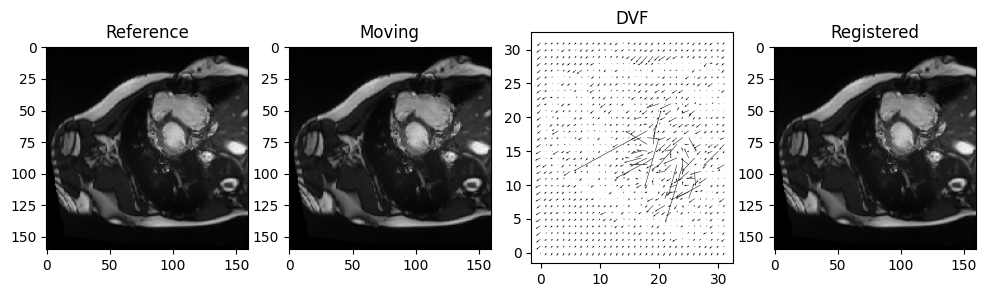

In [ ]:
import os
import re
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATASET ----------------
class ACDCDataset(Dataset):
    def __init__(self, root):
        self.pairs = []

        for patient in os.listdir(root):
            p_path = os.path.join(root, patient)
            if not os.path.isdir(p_path): continue

            files = os.listdir(p_path)

            frames = []
            for f in files:
                match = re.match(r".*frame(\d+)\.nii$", f)
                if match and "_gt" not in f and "_4d" not in f:
                    frames.append((int(match.group(1)), f))

            if len(frames) < 2: continue

            frames.sort(key=lambda x: x[0])

            ref = os.path.join(p_path, frames[0][1])
            mov = os.path.join(p_path, frames[-1][1])

            self.pairs.append((ref, mov))

        print("Total Pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ref_path, mov_path = self.pairs[idx]

        try:
            ref_img = nib.load(ref_path).get_fdata()
            mov_img = nib.load(mov_path).get_fdata()
        except:
            return self.__getitem__((idx+1)%len(self.pairs))

        diff = np.abs(ref_img - mov_img).sum(axis=(0,1))
        z = np.argmax(diff)

        ref = ref_img[:,:,z]
        mov = mov_img[:,:,z]

        ref = (ref-ref.min())/(ref.max()-ref.min()+1e-8)
        mov = (mov-mov.min())/(mov.max()-mov.min()+1e-8)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0),(160,160)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0),(160,160)).squeeze(0)

        x = torch.cat([ref,mov],0)

        return x, ref, mov

# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2)
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1],1))

        return self.out(d1)

# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid+dvf, align_corners=True)

# ---------------- NCC ----------------
def ncc(a,b):
    a = a - a.mean()
    b = b - b.mean()
    return (a*b).mean()/(torch.sqrt((a*a).mean()* (b*b).mean()) + 1e-8)

# ---------------- LOAD DATA ----------------
train_ds = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")
test_ds  = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/testing")

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)

# ---------------- TRAIN ----------------
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(),lr=1e-3)

for epoch in range(20):   # 🔥 increase epochs
    for x,ref,mov in train_loader:
        x,ref,mov = x.to(device),ref.to(device),mov.to(device)

        dvf = model(x)
        reg = warp(mov,dvf)

        loss = F.mse_loss(ref,reg) + (1-ssim(ref,reg,data_range=1))

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Epoch",epoch,"Loss:",loss.item())

# ---------------- TEST (PAPER STYLE) ----------------
model.train()   # keep dropout ON

ssim_total = 0
ncc_total = 0
count = 0

with torch.no_grad():
    for x,ref,mov in test_loader:
        x,ref,mov = x.to(device),ref.to(device),mov.to(device)

        samples = []
        for _ in range(10):   # Bayesian sampling
            samples.append(model(x))

        dvf = torch.mean(torch.stack(samples),dim=0)
        reg = warp(mov,dvf)

        s = ssim(ref,reg,data_range=1)
        n = ncc(ref,reg)

        ssim_total += s.item()
        ncc_total += n.item()
        count += 1

print("\n🔥 FINAL RESULTS")
print("SSIM:", ssim_total/count)
print("NCC :", ncc_total/count)

# ---------------- VISUALIZATION ----------------
x,ref,mov = next(iter(test_loader))
x,ref,mov = x.to(device),ref.to(device),mov.to(device)

dvf = model(x)
reg = warp(mov,dvf)

dvf_np = dvf.detach().cpu().squeeze().numpy()
dx,dy = dvf_np[0], dvf_np[1]

plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.title("Reference")
plt.imshow(reg.detach().cpu().squeeze().numpy(), cmap='gray')

plt.subplot(1,4,2)
plt.title("Moving")
plt.imshow(reg.detach().cpu().squeeze().numpy(), cmap='gray')

plt.subplot(1,4,3)
plt.title("DVF")
plt.quiver(dx[::5,::5],dy[::5,::5])

plt.subplot(1,4,4)
plt.title("Registered")
plt.imshow(reg.detach().cpu().squeeze().numpy(), cmap='gray')
plt.show()

In [ ]:
!pip install nibabel pytorch-msssim scipy

Total Images: 200
Epoch 0 Loss: 0.18454107642173767
Epoch 1 Loss: 0.11452817916870117
Epoch 2 Loss: 0.11123774200677872
Epoch 3 Loss: 0.11159350723028183
Epoch 4 Loss: 0.09334522485733032
Epoch 5 Loss: 0.06709786504507065
Epoch 6 Loss: 0.08023152500391006
Epoch 7 Loss: 0.06037873774766922
Epoch 8 Loss: 0.0684489980340004
Epoch 9 Loss: 0.08250021189451218


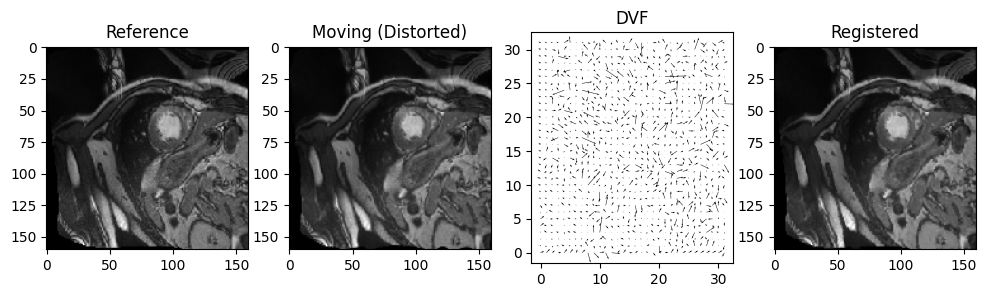

In [ ]:
import os
import re
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, map_coordinates

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- ELASTIC DEFORMATION ----------------
def elastic_deform(image, alpha=25, sigma=5):
    random_state = np.random.RandomState(None)
    shape = image.shape

    dx = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    dy = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (y+dy).reshape(-1), (x+dx).reshape(-1)

    return map_coordinates(image, indices, order=1).reshape(shape)

# ---------------- DATASET ----------------
class ACDCDataset(Dataset):
    def __init__(self, root):
        self.images = []

        for patient in os.listdir(root):
            p_path = os.path.join(root, patient)
            if not os.path.isdir(p_path): continue

            files = os.listdir(p_path)

            for f in files:
                if "frame" in f and "_gt" not in f and "_4d" not in f and f.endswith(".nii"):
                    self.images.append(os.path.join(p_path, f))

        print("Total Images:", len(self.images))

    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):
        path = self.images[idx]

        try:
            img = nib.load(path).get_fdata()
        except:
        # 🔥 skip bad file and move to next
            return self.__getitem__((idx + 1) % len(self.images))

        z = img.shape[2] // 2
        ref = img[:, :, z]

        ref = (ref - ref.min()) / (ref.max() - ref.min() + 1e-8)

    # elastic deformation
        mov = elastic_deform(ref)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0),(160,160)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0),(160,160)).squeeze(0)

        x = torch.cat([ref, mov], 0)

        return x, ref, mov



# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2)
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1],1))

        return self.out(d1)

# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid+dvf, align_corners=True)

# ---------------- LOAD DATA ----------------
dataset = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")

loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0   # 🔥 IMPORTANT (avoid worker crash)
)

# ---------------- TRAIN ----------------
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(),lr=1e-3)

for epoch in range(10):
    for x,ref,mov in loader:
        x,ref,mov = x.to(device),ref.to(device),mov.to(device)

        dvf = model(x)
        reg = warp(mov,dvf)

        loss = F.mse_loss(ref,reg) + (1-ssim(ref,reg,data_range=1))

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Epoch",epoch,"Loss:",loss.item())

# ---------------- VISUALIZATION ----------------
x,ref,mov = next(iter(loader))
x,ref,mov = x.to(device),ref.to(device),mov.to(device)

dvf = model(x)
reg = warp(mov,dvf)

# convert for plotting
ref_np = ref.detach().cpu().squeeze().numpy()
mov_np = mov.detach().cpu().squeeze().numpy()
reg_np = reg.detach().cpu().squeeze().numpy()

dvf_np = dvf.detach().cpu().squeeze().numpy()
dx,dy = dvf_np[0], dvf_np[1]

# ---------------- FIGURE ----------------
plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.title("Reference")
plt.imshow(ref_np, cmap='gray')

plt.subplot(1,4,2)
plt.title("Moving (Distorted)")
plt.imshow(mov_np, cmap='gray')

plt.subplot(1,4,3)
plt.title("DVF")
plt.quiver(dx[::5,::5], dy[::5,::5])

plt.subplot(1,4,4)
plt.title("Registered")
plt.imshow(reg_np, cmap='gray')

plt.show()

In [ ]:
!pip install nibabel pytorch-msssim scipy

Loaded 200 images from /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training
Loaded 100 images from /kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/testing
Epoch 0 Loss: 0.5489
Epoch 1 Loss: 0.2505
Epoch 2 Loss: 0.2125
Epoch 3 Loss: 0.1718
Epoch 4 Loss: 0.1208
Epoch 5 Loss: 0.1215
Epoch 6 Loss: 0.0828
Epoch 7 Loss: 0.1343
Epoch 8 Loss: 0.1266
Epoch 9 Loss: 0.1289
🔥 FINAL TEST SSIM: 0.9383553636074066


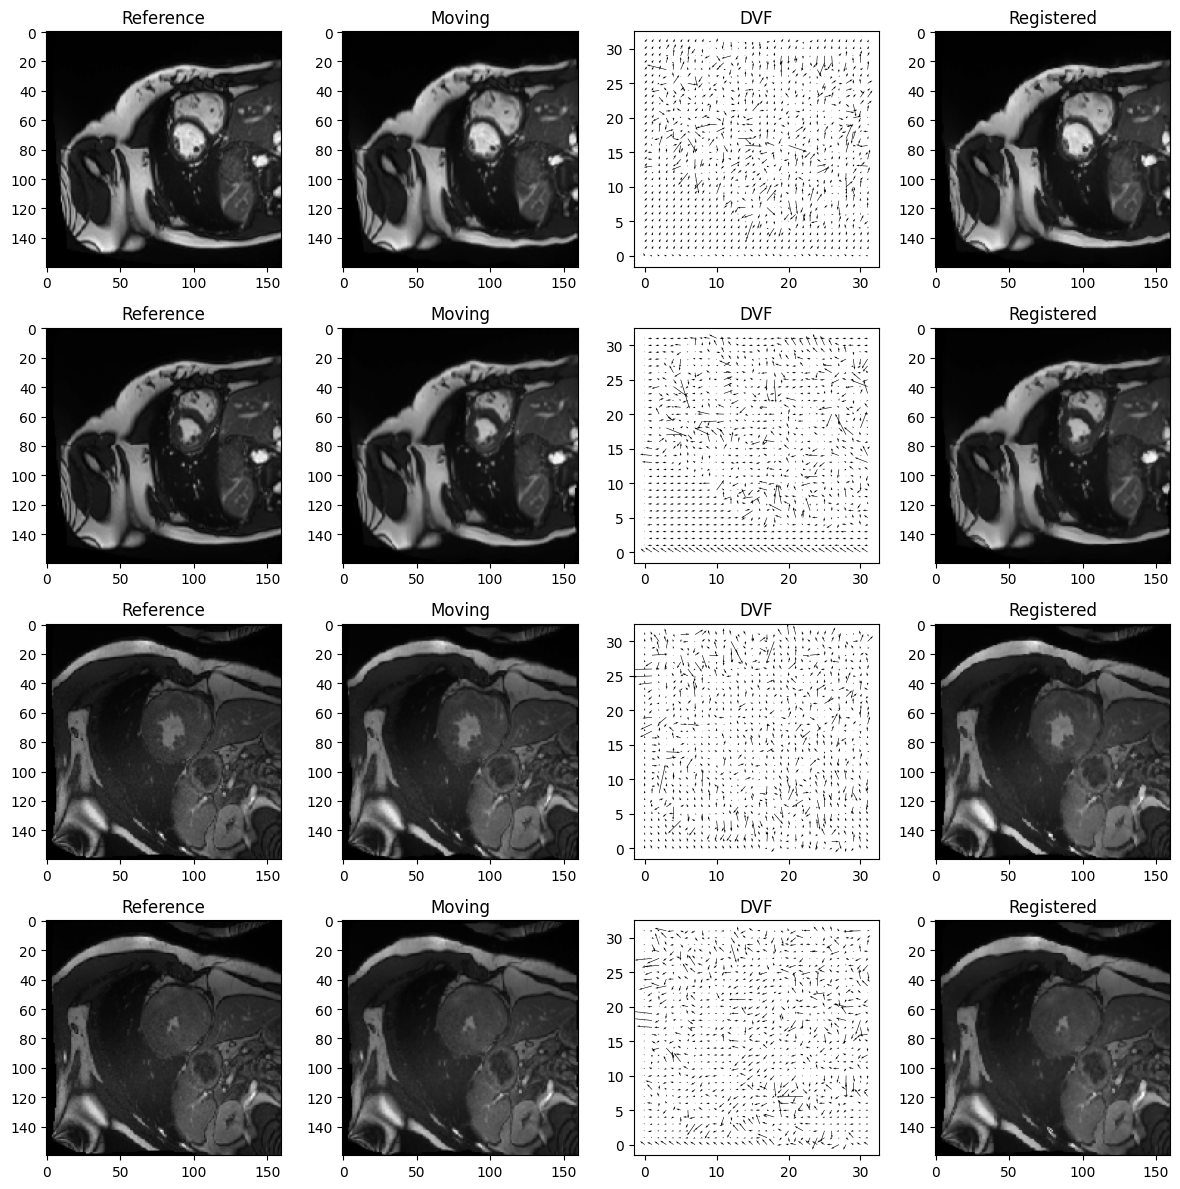

In [ ]:
import os
import re
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, map_coordinates

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- ELASTIC DEFORMATION ----------------
def elastic_deform(image, alpha=25, sigma=5):
    random_state = np.random.RandomState(None)
    shape = image.shape

    dx = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    dy = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (y+dy).reshape(-1), (x+dx).reshape(-1)

    return map_coordinates(image, indices, order=1).reshape(shape)

# ---------------- DATASET ----------------
class ACDCDataset(Dataset):
    def __init__(self, root):
        self.images = []

        for patient in os.listdir(root):
            p_path = os.path.join(root, patient)
            if not os.path.isdir(p_path):
                continue

            files = os.listdir(p_path)

            for f in files:
                if ("frame" in f and "_gt" not in f and "_4d" not in f and f.endswith(".nii")):
                    self.images.append(os.path.join(p_path, f))

        print(f"Loaded {len(self.images)} images from {root}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]

        try:
            img = nib.load(path).get_fdata()
        except:
            return self.__getitem__((idx + 1) % len(self.images))

        # pick slice
        z = img.shape[2] // 2
        ref = img[:, :, z]

        # normalize
        ref = (ref - ref.min()) / (ref.max() - ref.min() + 1e-8)

        # synthetic deformation (key step)
        mov = elastic_deform(ref)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0), size=(160,160)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0), size=(160,160)).squeeze(0)

        x = torch.cat([ref, mov], dim=0)

        return x, ref, mov

# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2)
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1],1))

        return self.out(d1)

# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid+dvf, align_corners=True)

# ---------------- LOAD DATA ----------------
train_dataset = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")
test_dataset  = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/testing")

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

# ---------------- TRAIN ----------------
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    for x, ref, mov in train_loader:
        x, ref, mov = x.to(device), ref.to(device), mov.to(device)

        dvf = model(x)
        reg = warp(mov, dvf)

        loss = F.mse_loss(ref, reg) + (1 - ssim(ref, reg, data_range=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} Loss: {loss.item():.4f}")

# ---------------- TEST METRIC ----------------
model.train()  # keep dropout active

total_ssim = 0
count = 0

with torch.no_grad():
    for x, ref, mov in test_loader:
        x, ref, mov = x.to(device), ref.to(device), mov.to(device)

        # Bayesian sampling
        samples = [model(x) for _ in range(5)]
        dvf = torch.mean(torch.stack(samples), dim=0)

        reg = warp(mov, dvf)

        score = ssim(ref, reg, data_range=1)
        total_ssim += score.item()
        count += 1

print("🔥 FINAL TEST SSIM:", total_ssim / count)

# ---------------- VISUALIZATION (TEST DATA) ----------------
num_samples = 4
plt.figure(figsize=(12, num_samples*3))

i = 1
count = 0

for x, ref, mov in test_loader:
    x, ref, mov = x.to(device), ref.to(device), mov.to(device)

    dvf = model(x)
    reg = warp(mov, dvf)

    ref_np = ref.detach().cpu().squeeze().numpy()
    mov_np = mov.detach().cpu().squeeze().numpy()
    reg_np = reg.detach().cpu().squeeze().numpy()

    dvf_np = dvf.detach().cpu().squeeze().numpy()
    dx, dy = dvf_np[0], dvf_np[1]

    plt.subplot(num_samples,4,i);   plt.imshow(ref_np, cmap='gray'); plt.title("Reference")
    plt.subplot(num_samples,4,i+1); plt.imshow(mov_np, cmap='gray'); plt.title("Moving")
    plt.subplot(num_samples,4,i+2); plt.quiver(dx[::5,::5], dy[::5,::5]); plt.title("DVF")
    plt.subplot(num_samples,4,i+3); plt.imshow(reg_np, cmap='gray'); plt.title("Registered")

    i += 4
    count += 1
    if count == num_samples:
        break

plt.tight_layout()
plt.show()

Total Patients: 100
Total Patients: 50
Epoch: 0 Loss: 0.557900071144104
Epoch: 1 Loss: 0.6588003635406494
Epoch: 2 Loss: 0.2205290049314499
Epoch: 3 Loss: 0.5597699880599976
Epoch: 4 Loss: 0.3804951012134552
Epoch: 5 Loss: 0.33913925290107727
Epoch: 6 Loss: 0.24626277387142181
Epoch: 7 Loss: 0.27855920791625977
Epoch: 8 Loss: 0.28589391708374023
Epoch: 9 Loss: 0.13603827357292175


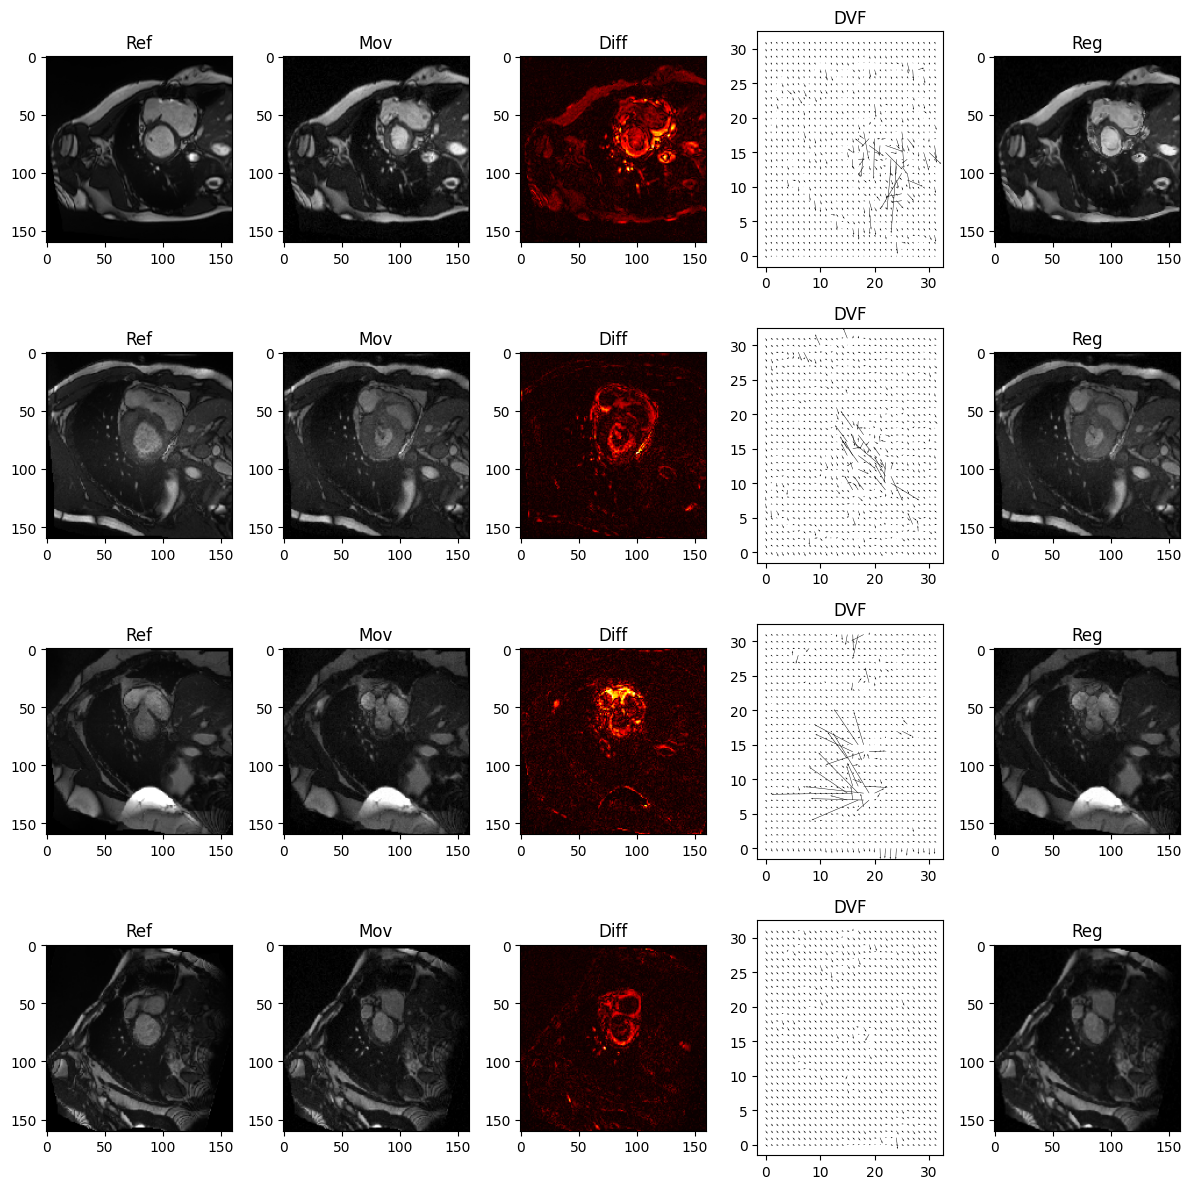

In [ ]:
import os, re
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, map_coordinates
from scipy.ndimage import gaussian_filter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- SMALL ELASTIC ----------------

def elastic_deform(image, alpha=25, sigma=5):
    random_state = np.random.RandomState(None)
    shape = image.shape

    dx = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    dy = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (y+dy).reshape(-1), (x+dx).reshape(-1)

    return map_coordinates(image, indices, order=1).reshape(shape)

def smoothness_loss(dvf):
    dx = torch.mean(torch.abs(dvf[:, :, :, :-1] - dvf[:, :, :, 1:]))
    dy = torch.mean(torch.abs(dvf[:, :, :-1, :] - dvf[:, :, 1:, :]))
    return dx + dy



# ---------------- DATASET ----------------
class ACDCDataset(Dataset):
    def __init__(self, root):
        self.pairs = []

        for patient in os.listdir(root):
            p_path = os.path.join(root, patient)
            if not os.path.isdir(p_path): continue

            files = os.listdir(p_path)

            frames = []
            for f in files:
                match = re.match(r".*frame(\d+)\.nii$", f)
                if match and "_gt" not in f and "_4d" not in f:
                    frames.append((int(match.group(1)), f))

            if len(frames) < 2: continue

            frames.sort(key=lambda x: x[0])

            ref = os.path.join(p_path, frames[0][1])   # ED
            mov = os.path.join(p_path, frames[-1][1])  # ES

            self.pairs.append((ref, mov))

        print("Total Patients:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ref_path, mov_path = self.pairs[idx]

        try:
            ref_img = nib.load(ref_path).get_fdata()
            mov_img = nib.load(mov_path).get_fdata()
        except:
            return self.__getitem__((idx+1)%len(self.pairs))

        # 🔥 slice with max motion
        diff = np.abs(ref_img - mov_img).sum(axis=(0,1))
        z = np.argmax(diff)

        ref = ref_img[:,:,z]
        mov = mov_img[:,:,z]

        # normalize
        ref = (ref-ref.min())/(ref.max()-ref.min()+1e-8)
        mov = (mov-mov.min())/(mov.max()-mov.min()+1e-8)

        # 🔥 ADD LIGHT SYNTHETIC VARIATION
        mov = mov + 0.02*np.random.randn(*mov.shape)   # noise
        mov = small_elastic(mov)                       # slight deformation

        mov = np.clip(mov, 0, 1)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0),(160,160)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0),(160,160)).squeeze(0)

        x = torch.cat([ref,mov],0)

        return x, ref, mov

# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU(),
                nn.Dropout2d(0.2)
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1],1))

        return self.out(d1)

# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid+dvf, align_corners=True)

# ---------------- LOAD ----------------
train_ds = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")
test_ds  = ACDCDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/testing")

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

# ---------------- TRAIN ----------------
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    for x, ref, mov in train_loader:
        x, ref, mov = x.to(device), ref.to(device), mov.to(device)

        dvf = model(x)
        reg = warp(mov, dvf)

        loss = (F.mse_loss(ref, reg)+ (1 - ssim(ref, reg, data_range=1))+ 0.2 * smoothness_loss(dvf))   # 🔥 tuned weight

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Epoch:", epoch, "Loss:", loss.item())

# ---------------- VISUALIZATION ----------------



# num_samples = 2
# plt.figure(figsize=(10, num_samples*3))

# i = 1

# for x, ref, mov in test_loader:
#     x, ref, mov = x.to(device), ref.to(device), mov.to(device)

#     # Bayesian smoothing
#     samples = [model(x) for _ in range(5)]
#     dvf = torch.mean(torch.stack(samples), dim=0)

#     reg = warp(mov, dvf)

#     # ---- numpy ----
#     ref_np = ref.detach().cpu().squeeze().numpy()
#     mov_np = mov.detach().cpu().squeeze().numpy()
#     reg_np = reg.detach().cpu().squeeze().numpy()

#     dvf_np = dvf.detach().cpu().squeeze().numpy()
#     dx, dy = dvf_np[0], dvf_np[1]

#     # 🔥 DVF magnitude (paper style)
#     dvf_mag = np.sqrt(dx**2 + dy**2)
#     dvf_mag = gaussian_filter(dvf_mag, sigma=2)

#     # 🔥 smooth diff (paper style)
#     diff_map = gaussian_filter(np.abs(ref_np - mov_np), sigma=1)

#     # ---- normalize for display ----
#     dvf_mag = (dvf_mag - dvf_mag.min()) / (dvf_mag.max() - dvf_mag.min() + 1e-8)
#     diff_map = (diff_map - diff_map.min()) / (diff_map.max() - diff_map.min() + 1e-8)

#     # ---- PLOT (paper layout) ----
#     plt.subplot(num_samples,4,i)
#     plt.imshow(ref_np, cmap='gray')
#     plt.title("Reference")
#     plt.axis('off')

#     plt.subplot(num_samples,4,i+1)
#     plt.imshow(mov_np, cmap='gray')
#     plt.title("Moving")
#     plt.axis('off')

#     plt.subplot(num_samples,4,i+2)
#     plt.imshow(dvf_mag, cmap='gray')   # 🔥 KEY CHANGE
#     plt.title("DVF")
#     plt.axis('off')

#     plt.subplot(num_samples,4,i+3)
#     plt.imshow(reg_np, cmap='gray')
#     plt.title("Registered")
#     plt.axis('off')

#     i += 4
#     if i > num_samples*4:
#         break

# plt.tight_layout()
# plt.show()

num_samples = 4
plt.figure(figsize=(12, num_samples*3))

i = 1
for x, ref, mov in test_loader:
    x, ref, mov = x.to(device), ref.to(device), mov.to(device)

    dvf = model(x)
    reg = warp(mov, dvf)

    ref_np = ref.detach().cpu().squeeze().numpy()
    mov_np = mov.detach().cpu().squeeze().numpy()
    reg_np = reg.detach().cpu().squeeze().numpy()

    diff_map = np.abs(ref_np - mov_np)

    dvf_np = dvf.detach().cpu().squeeze().numpy()
    dx, dy = dvf_np[0], dvf_np[1]

    plt.subplot(num_samples,5,i); plt.imshow(ref_np,cmap='gray'); plt.title("Ref")
    plt.subplot(num_samples,5,i+1); plt.imshow(mov_np,cmap='gray'); plt.title("Mov")
    plt.subplot(num_samples,5,i+2); plt.imshow(diff_map,cmap='hot'); plt.title("Diff")
    plt.subplot(num_samples,5,i+3); plt.quiver(dx[::5,::5],dy[::5,::5]); plt.title("DVF")
    plt.subplot(num_samples,5,i+4); plt.imshow(reg_np,cmap='gray'); plt.title("Reg")

    i += 5
    if i > num_samples*5:
        break

plt.tight_layout()
plt.show()

Total slices: 152
Epoch: 0 Loss: 0.8509798049926758
Epoch: 1 Loss: 0.261980265378952
Epoch: 2 Loss: 0.15866592526435852
Epoch: 3 Loss: 0.16886700689792633
Epoch: 4 Loss: 0.20343448221683502
Epoch: 5 Loss: 0.18958812952041626
Epoch: 6 Loss: 0.20837867259979248
Epoch: 7 Loss: 0.17551688849925995
Epoch: 8 Loss: 0.15714740753173828
Epoch: 9 Loss: 0.15565820038318634


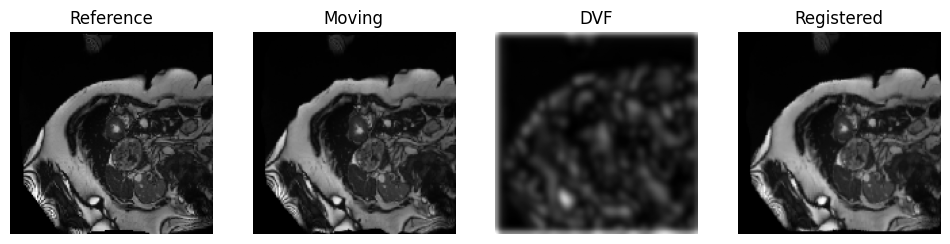

In [ ]:
import os, re
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter, map_coordinates
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- ELASTIC DEFORMATION ----------------
def elastic_deform(image, alpha=35, sigma=5):
    random_state = np.random.RandomState(None)
    shape = image.shape

    dx = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    dy = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (y+dy).reshape(-1), (x+dx).reshape(-1)

    return map_coordinates(image, indices, order=1).reshape(shape)

# ---------------- DATASET ----------------
class PaperDataset(Dataset):
    def __init__(self, root):
        self.slices = []

        for patient in os.listdir(root):
            p_path = os.path.join(root, patient)
            if not os.path.isdir(p_path): continue

            for file in os.listdir(p_path):
                if "frame" in file and "_gt" not in file and file.endswith(".nii"):

                    try:
                        img = nib.load(os.path.join(p_path, file)).get_fdata()
                    except:
                        continue

                    for z in range(img.shape[2]):
                        ref = img[:,:,z]

                        ref = (ref-ref.min())/(ref.max()-ref.min()+1e-8)
                        self.slices.append(ref)

        print("Total slices:", len(self.slices))

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        ref = self.slices[idx]

        # 🔥 generate moving on-the-fly (paper style)
        mov = elastic_deform(ref)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0),(150,150)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0),(150,150)).squeeze(0)

        x = torch.cat([ref, mov], dim=0)

        return x, ref, mov

# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()


        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU()
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)

    # 🔥 FIX: match size before concat
        if d2.shape != e2.shape:
            d2 = F.interpolate(d2, size=e2.shape[2:])

            d2 = self.dec2(torch.cat([d2,e2],1))

            d1 = self.up1(d2)

    # 🔥 FIX AGAIN
        if d1.shape != e1.shape:
            d1 = F.interpolate(d1, size=e1.shape[2:])

            d1 = self.dec1(torch.cat([d1,e1],1))

        return torch.tanh(self.out(d1))
# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid + 0.7*dvf, align_corners=True)  # 🔥 scaled

# ---------------- SMOOTHNESS LOSS ----------------
def smoothness_loss(dvf):
    dx = torch.mean(torch.abs(dvf[:,:,:,1:] - dvf[:,:,:,:-1]))
    dy = torch.mean(torch.abs(dvf[:,:,1:,:] - dvf[:,:,:-1,:]))
    return dx + dy

# ---------------- LOAD DATA ----------------
dataset = PaperDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")

loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

# ---------------- TRAIN ----------------
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    for x, ref, mov in loader:
        x, ref, mov = x.to(device), ref.to(device), mov.to(device)

        dvf = model(x)
        reg = warp(mov, dvf)

        loss = (
            F.mse_loss(ref, reg)
            + (1 - ssim(ref, reg, data_range=1))
            + 0.2 * smoothness_loss(dvf)
        )

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Epoch:", epoch, "Loss:", loss.item())

# ---------------- VISUALIZATION ----------------
from scipy.ndimage import gaussian_filter

x, ref, mov = next(iter(loader))
x, ref, mov = x.to(device), ref.to(device), mov.to(device)

dvf = model(x)
reg = warp(mov, dvf)

ref_np = ref[0].detach().cpu().squeeze().numpy()
mov_np = mov[0].detach().cpu().squeeze().numpy()
reg_np = reg[0].detach().cpu().squeeze().numpy()

dvf_np = dvf[0].detach().cpu().numpy()
dx, dy = dvf_np[0], dvf_np[1]

dvf_mag = np.sqrt(dx**2 + dy**2)
dvf_mag = gaussian_filter(dvf_mag, sigma=2)

plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.imshow(ref_np, cmap='gray')
plt.title("Reference")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(mov_np, cmap='gray')
plt.title("Moving")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(dvf_mag, cmap='gray')
plt.title("DVF")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(reg_np, cmap='gray')
plt.title("Registered")
plt.axis('off')

plt.show()

In [ ]:
!pip install nibabel pytorch-msssim scipy


Total slices: 152
Epoch: 0 Loss: 0.3577534854412079
Epoch: 1 Loss: 0.31523194909095764
Epoch: 2 Loss: 0.19148877263069153
Epoch: 3 Loss: 0.2075706273317337
Epoch: 4 Loss: 0.153639554977417
Epoch: 5 Loss: 0.14772328734397888
Epoch: 6 Loss: 0.10201944410800934
Epoch: 7 Loss: 0.09049717336893082
Epoch: 8 Loss: 0.13112349808216095
Epoch: 9 Loss: 0.1354561448097229
Epoch: 10 Loss: 0.10386470705270767
Epoch: 11 Loss: 0.08474396169185638
Epoch: 12 Loss: 0.11120932549238205
Epoch: 13 Loss: 0.08959725499153137
Epoch: 14 Loss: 0.06550572067499161
Epoch: 15 Loss: 0.07860282808542252
Epoch: 16 Loss: 0.13059955835342407
Epoch: 17 Loss: 0.09169743210077286
Epoch: 18 Loss: 0.06523623317480087
Epoch: 19 Loss: 0.059366580098867416
Epoch: 20 Loss: 0.08140477538108826
Epoch: 21 Loss: 0.06193295866250992
Epoch: 22 Loss: 0.079945407807827
Epoch: 23 Loss: 0.07304897904396057
Epoch: 24 Loss: 0.05972904711961746
Epoch: 25 Loss: 0.07413318008184433
Epoch: 26 Loss: 0.07406149059534073
Epoch: 27 Loss: 0.07342178

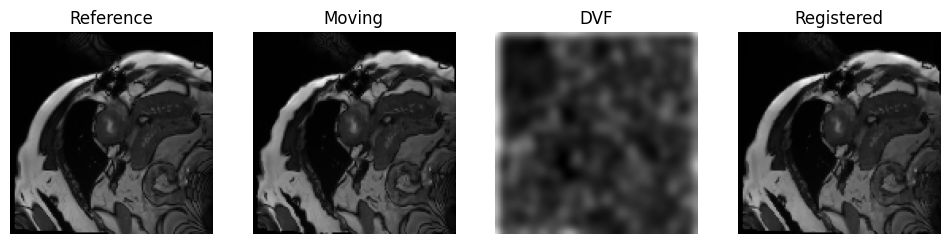

In [ ]:
import os
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter, map_coordinates
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- STRONG CONTROLLED DEFORMATION ----------------
def elastic_deform(image, alpha=60, sigma=6):
    random_state = np.random.RandomState(42)  # 🔥 fixed pattern (paper-like)

    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    dy = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (y+dy).reshape(-1), (x+dx).reshape(-1)

    return map_coordinates(image, indices, order=1).reshape(shape)

# ---------------- DATASET ----------------
class ForcedDataset(Dataset):
    def __init__(self, root):
        self.slices = []

        for patient in os.listdir(root):
            p_path = os.path.join(root, patient)
            if not os.path.isdir(p_path): continue

            for file in os.listdir(p_path):
                if "frame" in file and "_gt" not in file and file.endswith(".nii"):
                    try:
                        img = nib.load(os.path.join(p_path, file)).get_fdata()
                    except:
                        continue

                    for z in range(img.shape[2]):
                        s = img[:,:,z]
                        s = (s - s.min())/(s.max()-s.min()+1e-8)
                        self.slices.append(s)

        print("Total slices:", len(self.slices))

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        ref = self.slices[idx]

        # 🔥 FORCE strong deformation
        mov = elastic_deform(ref)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0),(128,128)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0),(128,128)).squeeze(0)

        x = torch.cat([ref, mov], dim=0)

        return x, ref, mov

# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU()
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = F.interpolate(d2, size=e2.shape[2:])
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = F.interpolate(d1, size=e1.shape[2:])
        d1 = self.dec1(torch.cat([d1,e1],1))

        return torch.tanh(self.out(d1))

# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid + 1.0*dvf, align_corners=True)  # 🔥 stronger warp

# ---------------- SMOOTHNESS LOSS ----------------
def smoothness_loss(dvf):
    dx = torch.mean(torch.abs(dvf[:,:,:,1:] - dvf[:,:,:,:-1]))
    dy = torch.mean(torch.abs(dvf[:,:,1:,:] - dvf[:,:,:-1,:]))
    return dx + dy
# ---------------- DATA ----------------
dataset = ForcedDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ---------------- TRAIN ----------------
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(30):   # 🔥 LONG TRAINING
    for x, ref, mov in loader:
        x, ref, mov = x.to(device), ref.to(device), mov.to(device)

        dvf = model(x)
        reg = warp(mov, dvf)

        loss = (
            2.0*F.mse_loss(ref, reg) +
            (1 - ssim(ref, reg, data_range=1))
        )

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Epoch:", epoch, "Loss:", loss.item())

# ---------------- TEST ----------------
x, ref, mov = next(iter(loader))
x, ref, mov = x.to(device), ref.to(device), mov.to(device)

dvf = model(x)
reg = warp(mov, dvf)

print("Before:", ssim(ref, mov, data_range=1).item())
print("After :", ssim(ref, reg, data_range=1).item())

# ---------------- VISUALIZATION ----------------
from scipy.ndimage import gaussian_filter

ref_np = ref[0].cpu().detach().squeeze().numpy()
mov_np = mov[0].cpu().detach().squeeze().numpy()
reg_np = reg[0].cpu().detach().squeeze().numpy()

dvf_np = dvf[0].cpu().detach().numpy()
dx, dy = dvf_np[0], dvf_np[1]

dvf_mag = np.sqrt(dx**2 + dy**2)
dvf_mag = gaussian_filter(dvf_mag, sigma=3)

dvf_mag = (dvf_mag - dvf_mag.min())/(dvf_mag.max()-dvf_mag.min()+1e-8)

plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.imshow(ref_np,cmap='gray'); plt.title("Reference"); plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(mov_np,cmap='gray'); plt.title("Moving"); plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(dvf_mag,cmap='gray'); plt.title("DVF"); plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(reg_np,cmap='gray'); plt.title("Registered"); plt.axis('off')

plt.show()

Total slices: 152
Epoch: 0 Loss: 0.3151921331882477
Epoch: 1 Loss: 0.2312057763338089
Epoch: 2 Loss: 0.2617906332015991
Epoch: 3 Loss: 0.19734543561935425
Epoch: 4 Loss: 0.13096076250076294
Epoch: 5 Loss: 0.15349848568439484
Epoch: 6 Loss: 0.16482152044773102
Epoch: 7 Loss: 0.13704803586006165
Epoch: 8 Loss: 0.15054196119308472
Epoch: 9 Loss: 0.10026621073484421
Epoch: 10 Loss: 0.09921496361494064
Epoch: 11 Loss: 0.13368624448776245
Epoch: 12 Loss: 0.10467535257339478
Epoch: 13 Loss: 0.09372992068529129
Epoch: 14 Loss: 0.11029965430498123
Epoch: 15 Loss: 0.09225687384605408
Epoch: 16 Loss: 0.06567901372909546
Epoch: 17 Loss: 0.08734219521284103
Epoch: 18 Loss: 0.11223170161247253
Epoch: 19 Loss: 0.11001810431480408
Epoch: 20 Loss: 0.10589791089296341
Epoch: 21 Loss: 0.08157502114772797
Epoch: 22 Loss: 0.10517159104347229
Epoch: 23 Loss: 0.07392620295286179
Epoch: 24 Loss: 0.08552944660186768
Epoch: 25 Loss: 0.09198976308107376
Epoch: 26 Loss: 0.07822743058204651
Epoch: 27 Loss: 0.08091

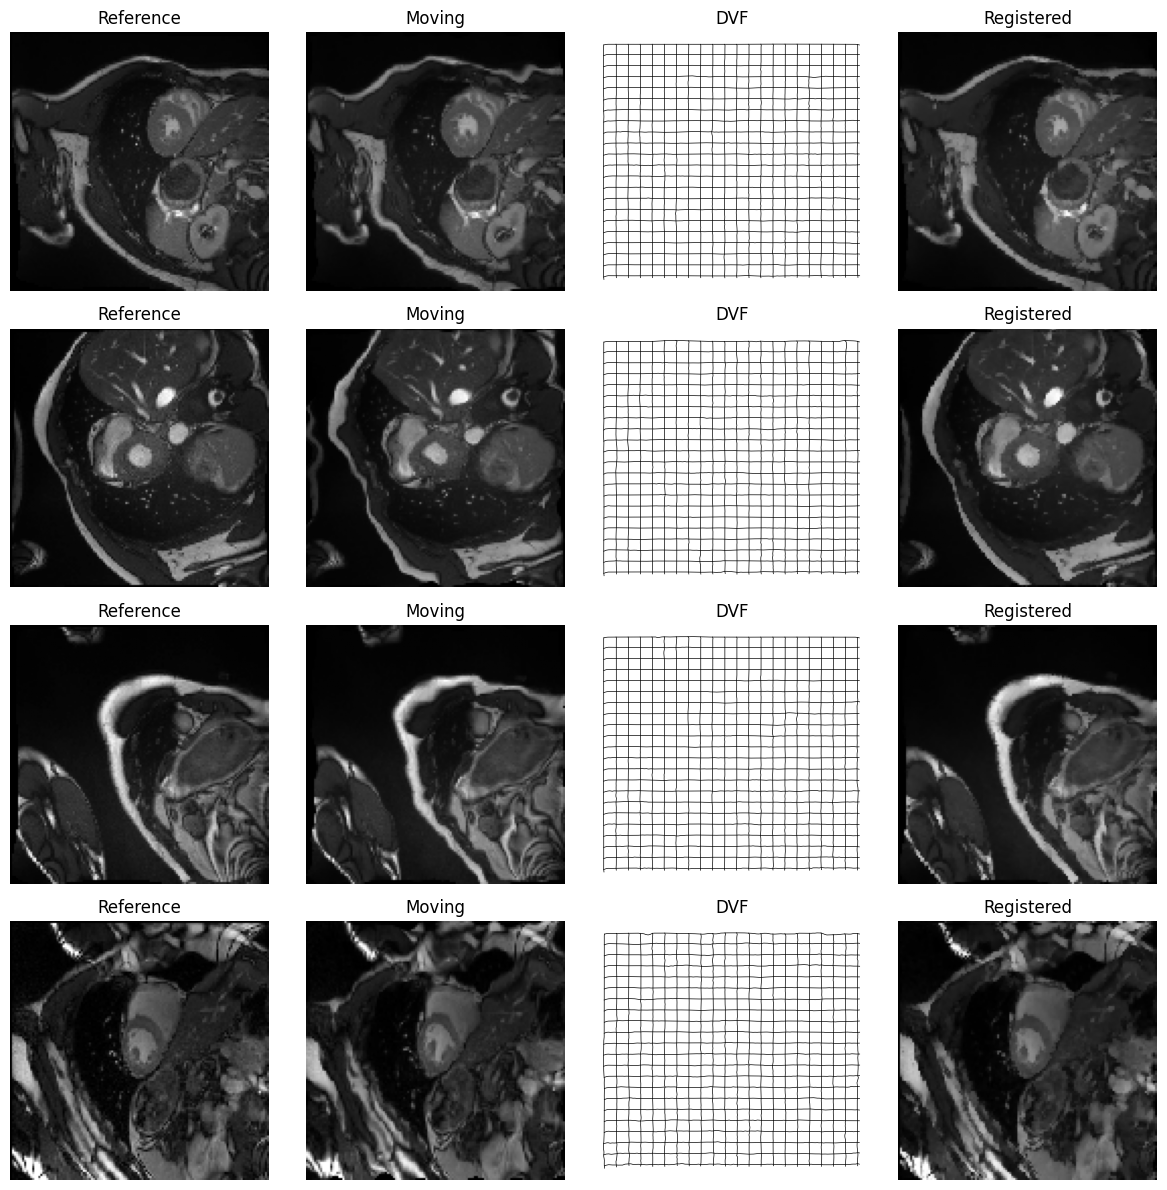

In [ ]:
import os
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter, map_coordinates
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- STRONG CONTROLLED DEFORMATION ----------------
def elastic_deform(image, alpha=60, sigma=6):
    random_state = np.random.RandomState(42)  # 🔥 fixed pattern (paper-like)

    shape = image.shape
    dx = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha
    dy = gaussian_filter((random_state.rand(*shape)*2-1), sigma)*alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (y+dy).reshape(-1), (x+dx).reshape(-1)

    return map_coordinates(image, indices, order=1).reshape(shape)

# ---------------- DATASET ----------------
class ForcedDataset(Dataset):
    def __init__(self, root):
        self.slices = []

        for patient in os.listdir(root):
            p_path = os.path.join(root, patient)
            if not os.path.isdir(p_path): continue

            for file in os.listdir(p_path):
                if "frame" in file and "_gt" not in file and file.endswith(".nii"):
                    try:
                        img = nib.load(os.path.join(p_path, file)).get_fdata()
                    except:
                        continue

                    for z in range(img.shape[2]):
                        s = img[:,:,z]
                        s = (s - s.min())/(s.max()-s.min()+1e-8)
                        self.slices.append(s)

        print("Total slices:", len(self.slices))

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        ref = self.slices[idx]

        # 🔥 FORCE strong deformation
        mov = elastic_deform(ref)

        ref = torch.tensor(ref).unsqueeze(0).float()
        mov = torch.tensor(mov).unsqueeze(0).float()

        ref = F.interpolate(ref.unsqueeze(0),(128,128)).squeeze(0)
        mov = F.interpolate(mov.unsqueeze(0),(128,128)).squeeze(0)

        x = torch.cat([ref, mov], dim=0)

        return x, ref, mov

# ---------------- MODEL ----------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1),
                nn.ReLU(),
                nn.Conv2d(o,o,3,padding=1),
                nn.ReLU()
            )

        self.enc1 = block(2,32)
        self.enc2 = block(32,64)
        self.enc3 = block(64,128)

        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = block(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = block(64,32)

        self.out = nn.Conv2d(32,2,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.up2(e3)
        d2 = F.interpolate(d2, size=e2.shape[2:])
        d2 = self.dec2(torch.cat([d2,e2],1))

        d1 = self.up1(d2)
        d1 = F.interpolate(d1, size=e1.shape[2:])
        d1 = self.dec1(torch.cat([d1,e1],1))

        return torch.tanh(self.out(d1))

# ---------------- WARP ----------------
def warp(img, dvf):
    B,C,H,W = img.size()

    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1,1,H,device=img.device),
        torch.linspace(-1,1,W,device=img.device),
        indexing='ij'
    )

    grid = torch.stack((grid_x,grid_y),2).unsqueeze(0)
    dvf = dvf.permute(0,2,3,1)

    return F.grid_sample(img, grid + 1.0*dvf, align_corners=True)  # 🔥 stronger warp

# ---------------- SMOOTHNESS LOSS ----------------
def smoothness_loss(dvf):
    dx = torch.mean((dvf[:,:,:,1:] - dvf[:,:,:,:-1])**2)
    dy = torch.mean((dvf[:,:,1:,:] - dvf[:,:,:-1,:])**2)
    return dx + dy

def show_grid(dvf, step=6):
    dvf = dvf.detach().cpu().squeeze().numpy()
    dx, dy = dvf[0], dvf[1]

    H, W = dx.shape
    grid_y, grid_x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

    new_x = grid_x + dx*10   # 🔥 amplify for visibility
    new_y = grid_y + dy*10

    for i in range(0, H, step):
        plt.plot(new_x[i,:], new_y[i,:], color='black', linewidth=0.5)
    for j in range(0, W, step):
        plt.plot(new_x[:,j], new_y[:,j], color='black', linewidth=0.5)

    plt.gca().invert_yaxis()
    plt.axis('off')
# ---------------- DATA ----------------
dataset = ForcedDataset("/kaggle/input/datasets/lightyagami06/acdc-slices/ACDC/database/training")
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ---------------- TRAIN ----------------
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(30):   # 🔥 LONG TRAINING
    for x, ref, mov in loader:
        x, ref, mov = x.to(device), ref.to(device), mov.to(device)

        dvf = model(x)
        reg = warp(mov, dvf)

        loss = (
            2.0 * F.mse_loss(ref, reg)
            + (1 - ssim(ref, reg, data_range=1))
            + 0.5 * smoothness_loss(dvf)   # 🔥 increased weight
        )
        opt.zero_grad()
        loss.backward()
        opt.step()

    print("Epoch:", epoch, "Loss:", loss.item())

# ---------------- TEST ----------------
x, ref, mov = next(iter(loader))
x, ref, mov = x.to(device), ref.to(device), mov.to(device)

dvf = model(x)
reg = warp(mov, dvf)

print("Before:", ssim(ref, mov, data_range=1).item())
print("After :", ssim(ref, reg, data_range=1).item())

# ---------------- VISUALIZATION ----------------
from scipy.ndimage import gaussian_filter

# ---------------- FINAL MULTI VISUALIZATION ----------------
num_samples = 4
plt.figure(figsize=(12, num_samples*3))

i = 1

for x, ref, mov in loader:   # 🔥 iterate over multiple samples
    x, ref, mov = x.to(device), ref.to(device), mov.to(device)

    dvf = model(x)
    reg = warp(mov, dvf)

    # SSIM check
    print("Before:", ssim(ref, mov, data_range=1).item(),
          "After:", ssim(ref, reg, data_range=1).item())

    ref_np = ref[0].cpu().detach().squeeze().numpy()
    mov_np = mov[0].cpu().detach().squeeze().numpy()
    reg_np = reg[0].cpu().detach().squeeze().numpy()

    dvf_np = dvf[0].cpu().detach().numpy()
    dx, dy = dvf_np[0], dvf_np[1]

    # -------- DVF GRID (PAPER STYLE) --------
    H, W = dx.shape
    grid_y, grid_x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

    new_x = grid_x + dx*10   # amplify for visibility
    new_y = grid_y + dy*10

    # -------- PLOT --------
    plt.subplot(num_samples,4,i)
    plt.imshow(ref_np, cmap='gray')
    plt.title("Reference")
    plt.axis('off')

    plt.subplot(num_samples,4,i+1)
    plt.imshow(mov_np, cmap='gray')
    plt.title("Moving")
    plt.axis('off')

    plt.subplot(num_samples,4,i+2)
    for k in range(0, H, 6):
        plt.plot(new_x[k,:], new_y[k,:], color='black', linewidth=0.5)
    for k in range(0, W, 6):
        plt.plot(new_x[:,k], new_y[:,k], color='black', linewidth=0.5)

    plt.gca().invert_yaxis()
    plt.title("DVF")
    plt.axis('off')

    plt.subplot(num_samples,4,i+3)
    plt.imshow(reg_np, cmap='gray')
    plt.title("Registered")
    plt.axis('off')

    i += 4
    if i > num_samples*4:
        break

plt.tight_layout()
plt.show()

In [ ]:
from pytorch_msssim import ssim

def compute_ssim(ref, reg):
    return ssim(ref, reg, data_range=1.0).item()

import torch.nn.functional as F

def compute_mse(ref, reg):
    return F.mse_loss(ref, reg).item()

def compute_ncc(ref, reg):
    ref_mean = torch.mean(ref)
    reg_mean = torch.mean(reg)

    num = torch.sum((ref - ref_mean) * (reg - reg_mean))
    den = torch.sqrt(torch.sum((ref - ref_mean)**2) * torch.sum((reg - reg_mean)**2) + 1e-8)

    return (num / den).item()

from scipy.spatial.distance import directed_hausdorff
import numpy as np

def compute_hd(ref, reg):
    ref_np = ref.cpu().detach().squeeze().numpy()
    reg_np = reg.cpu().detach().squeeze().numpy()

    # threshold → binary masks
    ref_bin = ref_np > 0.5
    reg_bin = reg_np > 0.5

    ref_pts = np.argwhere(ref_bin)
    reg_pts = np.argwhere(reg_bin)

    if len(ref_pts) == 0 or len(reg_pts) == 0:
        return 0

    hd1 = directed_hausdorff(ref_pts, reg_pts)[0]
    hd2 = directed_hausdorff(reg_pts, ref_pts)[0]

    return max(hd1, hd2)

ssim_list = []
mse_list = []
ncc_list = []
hd_list = []

for x, ref, mov in loader:
    x, ref, mov = x.to(device), ref.to(device), mov.to(device)

    dvf = model(x)
    reg = warp(mov, dvf)

    ssim_list.append(compute_ssim(ref, reg))
    mse_list.append(compute_mse(ref, reg))
    ncc_list.append(compute_ncc(ref, reg))
    hd_list.append(compute_hd(ref, reg))


print("SSIM:", np.mean(ssim_list))
print("MSE :", np.mean(mse_list))
print("NCC :", np.mean(ncc_list))
print("HD  :", np.mean(hd_list))


🔥 FINAL RESULTS 🔥
SSIM: 0.9304191925023731
MSE : 0.0010274297980542638
NCC : 0.9834177211711281
HD  : 13.78999565392681
